# ICESat-2 ATL21

ATL21 is the gridded sea surface height anomaly (SSHA) product for the poles. Because it is a gridded product, we can use `point-collocation` to do matchups. Other ICESat-2 products like ATL07 are along track (lines) and `point-collocation` will not work for those data.

ATL21 has

* Daily Arctic/Antarctic SSHA fields
* Monthly averaged SSHA fields

The granules are h5 grouped netcdf files. It has monthly, daily, and metadata all in one netcdf. Because the points are in the far north (poles), we cannot use standard euclidean distance on lat/lon degrees. Read about point matchups near the poles [here](https://tutorial.xarray.dev/advanced/indexing/why-trees.html#the-problem-with-geographic-coordinates). We can pass in `spatial_method="xoak-haversine"` to use a distance metric designed for the globe and that works at the poles.

*Note: In a virtual machine in AWS us-west-2, where NASA cloud data is, the point matchups are fast. In Colab, say, your compute is not in the same data region nor provider, and the same matchups might take 10x longer.*

## Prerequisites

The examples here use NASA EarthData and you need to have an account with EarthData. Make sure you can login.

In [ ]:
# if needed
pip install point-collocation

In [1]:
import earthaccess
earthaccess.login()

## Generate some points over the arctic

In [1]:
import numpy as np
import pandas as pd

n_points = 50

# generate Arctic points (lat > 60)
points = []
while len(points) < n_points:
    batch = 500
    lat = np.degrees(np.arcsin(np.random.uniform(-1, 1, batch)))
    lon = np.random.uniform(-180, 180, batch)

    mask = lat > 75
    for la, lo in zip(lat[mask], lon[mask]):
        points.append((la, lo))
        if len(points) >= n_points:
            break

lat, lon = np.array(points).T

# random dates after Oct 2018
start = pd.Timestamp("2018-10-01")
end = pd.Timestamp.now()

days = pd.date_range(start, end, freq="D")
date = np.random.choice(days, n_points)

# dataframe
df = pd.DataFrame({
    "lat": lat,
    "lon": lon,
    "date": date
})

print(df.head())

         lat         lon       date
0  80.064771  151.625244 2025-10-04
1  79.675933  -75.975839 2018-11-09
2  77.683725 -112.654124 2019-01-16
3  75.965299   69.669734 2025-08-21
4  77.997156   69.883494 2022-07-11


### Next get the granule plan

In [2]:
import point_collocation as pc
import pandas as pd
short_name="ATL21"
plan = pc.plan(
    df,
    data_source="earthaccess",
    source_kwargs={
        "short_name": short_name,
        "version": "004"
    }
)

In [5]:
# Some points are probably over land
plan.summary(n=0)

Plan: 50 points → 33 unique granule(s)
  Points with 0 matches : 6
  Points with >1 matches: 0
  Time buffer: 0 days 00:00:00


## First let's open one granule

This will allow us to see what groups are in the granules.

In [3]:
plan.open_dataset(0, open_method="datatree")

open_method: {'xarray_open': 'datatree', 'open_kwargs': {'chunks': {}, 'engine': 'h5netcdf', 'decode_timedelta': False}, 'merge': None, 'coords': 'auto', 'set_coords': True, 'dim_renames': None, 'auto_align_phony_dims': None}
Geolocation: DataTree returned without merging — no geolocation summary.


<xarray.DataTree>
Group: /
│   Dimensions:        (grid_y: 448, grid_x: 304)
│   Coordinates:
│     * grid_y         (grid_y) float64 4kB 5.838e+06 5.812e+06 ... -5.338e+06
│     * grid_x         (grid_x) float64 2kB -3.838e+06 -3.812e+06 ... 3.738e+06
│   Data variables:
│       crs            int8 1B ...
│       grid_lat       (grid_y, grid_x) float64 1MB dask.array<chunksize=(448, 304), meta=np.ndarray>
│       grid_lon       (grid_y, grid_x) float64 1MB dask.array<chunksize=(448, 304), meta=np.ndarray>
│       land_mask_map  (grid_y, grid_x) float64 1MB dask.array<chunksize=(448, 304), meta=np.ndarray>
│   Attributes: (12/46)
│       short_name:                         ATL21
│       level:                              L3B
│       description:                        This data set (ATL21) contains daily ...
│       Conventions:                        CF-1.7
│       contributor_name:                   Alek Petty (alek.a.petty@nasa.gov), R...
│       contributor_role:                   Investigator, Investigator, Investiga...
│       ...                                 ...
│       processing_level:                   3B
│       references:                         http://nsidc.org/data/icesat2/data.html
│       project:                            ICESat-2 > Ice, Cloud, and land Eleva...
│       instrument:                         ATLAS > Advanced Topographic Laser Al...
│       platform:                           ICESat-2 > Ice, Cloud, and land Eleva...
│       source:                             Spacecraft
├── Group: /ancillary_data
│   │   Dimensions:              (phony_dim_0: 1)
│   │   Dimensions without coordinates: phony_dim_0
│   │   Data variables: (12/24)
│   │       atlas_sdp_gps_epoch  (phony_dim_0) datetime64[ns] 8B dask.array<chunksize=(1,), meta=np.ndarray>
│   │       control              (phony_dim_0) |S100000 100kB dask.array<chunksize=(1,), meta=np.ndarray>
│   │       data_end_utc         (phony_dim_0) |S27 27B dask.array<chunksize=(1,), meta=np.ndarray>
│   │       data_start_utc       (phony_dim_0) |S27 27B dask.array<chunksize=(1,), meta=np.ndarray>
│   │       end_cycle            (phony_dim_0) int32 4B dask.array<chunksize=(1,), meta=np.ndarray>
│   │       end_delta_time       (phony_dim_0) datetime64[ns] 8B dask.array<chunksize=(1,), meta=np.ndarray>
│   │       ...                   ...
│   │       start_gpssow         (phony_dim_0) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
│   │       start_gpsweek        (phony_dim_0) int32 4B dask.array<chunksize=(1,), meta=np.ndarray>
│   │       start_orbit          (phony_dim_0) int32 4B dask.array<chunksize=(1,), meta=np.ndarray>
│   │       start_region         (phony_dim_0) int32 4B dask.array<chunksize=(1,), meta=np.ndarray>
│   │       start_rgt            (phony_dim_0) int32 4B dask.array<chunksize=(1,), meta=np.ndarray>
│   │       version              (phony_dim_0) |S80 80B dask.array<chunksize=(1,), meta=np.ndarray>
│   │   Attributes:
│   │       description:  Contains information ancillary to the data product. This ma...
│   ├── Group: /ancillary_data/beam_selection
│   │       Dimensions:            (phony_dim_1: 1)
│   │       Dimensions without coordinates: phony_dim_1
│   │       Data variables:
│   │           proc_atl21_spot_1  (phony_dim_1) int8 1B dask.array<chunksize=(1,), meta=np.ndarray>
│   │           proc_atl21_spot_2  (phony_dim_1) int8 1B dask.array<chunksize=(1,), meta=np.ndarray>
│   │           proc_atl21_spot_3  (phony_dim_1) int8 1B dask.array<chunksize=(1,), meta=np.ndarray>
│   │           proc_atl21_spot_4  (phony_dim_1) int8 1B dask.array<chunksize=(1,), meta=np.ndarray>
│   │           proc_atl21_spot_5  (phony_dim_1) int8 1B dask.array<chunksize=(1,), meta=np.ndarray>
│   │           proc_atl21_spot_6  (phony_dim_1) int8 1B dask.array<chunksize=(1,), meta=np.ndarray>
│   │       Attributes:
│   │           description:  These parameters control which laser beam spots from ATL10 ...
│   └── Group: /ancillary_data

### Specify a `open_method` profile

Now that we know what the groups are and what the latitude and longitude are called, we can set up a `open_method` profile. This is used to tell `point-collocation` how to open the file (`open_dataset` or `open_datatree` and what groups (if any) to merge. Note, `open_dataset` and merge is faster than `open_datatree` and merge.

Let's open one file and plot our points on that data. A bunch of points are on land and those will be NaN. A few points are on white (NaN) and those will be NaN also.

In [4]:
%%time
icesat2_atl21 = {
    'xarray_open': 'dataset',
    'merge': ['/', '/monthly'],
    'coords': {'lat': 'grid_lat', 'lon': 'grid_lon'},
    'set_coords': True,
    'open_kwargs': {'phony_dims':'access'}
}
ds = plan.open_dataset(0, open_method=icesat2_atl21)
ds

open_method: {'xarray_open': 'dataset', 'merge': ['/', '/monthly'], 'coords': {'lat': 'grid_lat', 'lon': 'grid_lon'}, 'set_coords': True, 'open_kwargs': {'phony_dims': 'access', 'chunks': {}, 'engine': 'h5netcdf', 'decode_timedelta': False}, 'dim_renames': None, 'auto_align_phony_dims': None, 'merge_kwargs': {}}
Geolocation specified: ('grid_lon', 'grid_lat') — lon dims=('grid_y', 'grid_x'), lat dims=('grid_y', 'grid_x')
Points columns used: y='lat', x='lon', time='date'
CPU times: user 2.37 s, sys: 9.98 ms, total: 2.38 s
Wall time: 2.62 s


<xarray.Dataset> Size: 8MB
Dimensions:                        (grid_y: 448, grid_x: 304, phony_dim_0: 1)
Coordinates:
  * grid_y                         (grid_y) float64 4kB 5.838e+06 ... -5.338e+06
  * grid_x                         (grid_x) float64 2kB -3.838e+06 ... 3.738e+06
    grid_lat                       (grid_y, grid_x) float64 1MB dask.array<chunksize=(448, 304), meta=np.ndarray>
    grid_lon                       (grid_y, grid_x) float64 1MB dask.array<chunksize=(448, 304), meta=np.ndarray>
Dimensions without coordinates: phony_dim_0
Data variables:
    crs                            int8 1B ...
    land_mask_map                  (grid_y, grid_x) float64 1MB dask.array<chunksize=(448, 304), meta=np.ndarray>
    delta_time_beg                 (phony_dim_0) datetime64[ns] 8B dask.array<chunksize=(1,), meta=np.ndarray>
    delta_time_end                 (phony_dim_0) datetime64[ns] 8B dask.array<chunksize=(1,), meta=np.ndarray>
    mean_ssha                      (grid_y, grid_x) float32 545kB dask.array<chunksize=(448, 304), meta=np.ndarray>
    mean_weighted_earth_free2mean  (grid_y, grid_x) float32 545kB dask.array<chunksize=(448, 304), meta=np.ndarray>
    mean_weighted_geoid            (grid_y, grid_x) float32 545kB dask.array<chunksize=(448, 304), meta=np.ndarray>
    mean_weighted_geoid_free2mean  (grid_y, grid_x) float32 545kB dask.array<chunksize=(448, 304), meta=np.ndarray>
    mean_weighted_mss              (grid_y, grid_x) float32 545kB dask.array<chunksize=(448, 304), meta=np.ndarray>
    n_refsurfs                     (grid_y, grid_x) float64 1MB dask.array<chunksize=(448, 304), meta=np.ndarray>
    sigma                          (grid_y, grid_x) float32 545kB dask.array<chunksize=(448, 304), meta=np.ndarray>
Attributes: (12/46)
    short_name:                         ATL21
    level:                              L3B
    description:                        This data set (ATL21) contains daily ...
    Conventions:                        CF-1.7
    contributor_name:                   Alek Petty (alek.a.petty@nasa.gov), R...
    contributor_role:                   Investigator, Investigator, Investiga...
    ...                                 ...
    processing_level:                   3B
    references:                         http://nsidc.org/data/icesat2/data.html
    project:                            ICESat-2 > Ice, Cloud, and land Eleva...
    instrument:                         ATLAS > Advanced Topographic Laser Al...
    platform:                           ICESat-2 > Ice, Cloud, and land Eleva...
    source:                             Spacecraft

## Specify `spatial_method="xoak-haversine"`

If we plot the points, we see that they are clustered around the North Pole. A kdtree, treates lat/lon as if they are euclidian, but near the pole 1 degree of latitude is very different than 1 degree of longitude. Thus kdtrees do poorly near the poles. Instead, we can use a Ball tree with the haversine metric.

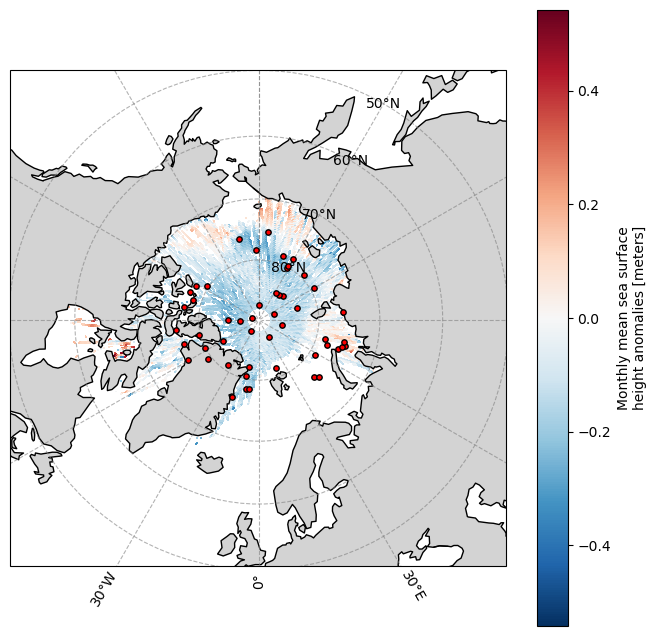

In [5]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

fig = plt.figure(figsize=(8,8))
ax = plt.axes(projection=ccrs.NorthPolarStereo())

# plot the field
ds.mean_ssha.plot.pcolormesh(
    x="grid_lon",
    y="grid_lat",
    transform=ccrs.PlateCarree(),
    ax=ax,
    shading="auto",
    add_colorbar=True,
)

ax.coastlines()
ax.add_feature(cfeature.LAND, facecolor="lightgray")

# Arctic extent
ax.set_extent([-180, 180, 50, 90], crs=ccrs.PlateCarree())

# gridlines
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.8,
    color="gray",
    alpha=0.6,
    linestyle="--",
)

gl.top_labels = False
gl.right_labels = False
gl.xlocator = plt.FixedLocator(np.arange(-180, 181, 30))
gl.ylocator = plt.FixedLocator(np.arange(50, 91, 10))

# ---- add points from dataframe ----
ax.scatter(
    df.lon,
    df.lat,
    transform=ccrs.PlateCarree(),
    s=15,
    color="red",
    edgecolor="black",
    zorder=10,
)

plt.show()

In [6]:
%%time
# this takes about 2 minutes
res = pc.matchup(plan, 
                 variables = ["mean_ssha"], 
                 open_method=icesat2_atl21,
                 spatial_method="xoak-haversine")

CPU times: user 1min 39s, sys: 300 ms, total: 1min 39s
Wall time: 1min 46s


The full `res` output shows the granules and granules closest lat/lon. Here is just the matchups.

In [7]:
res[['lat', 'granule_lat', 
     'lon', 'granule_lon', 'mean_ssha']].dropna(subset=['mean_ssha'])

,lat,granule_lat,lon,granule_lon,mean_ssha
5,75.014142,74.953152,73.477882,73.715078,-0.249200
7,84.306776,84.349182,134.232624,133.830861,-0.127871
8,84.654167,84.550081,140.629343,141.072456,-0.220477
13,79.677602,79.750895,-123.090587,-122.680555,-0.123039
16,84.934332,84.944443,-89.301292,-90.000000,-0.137447
17,78.613427,78.625932,73.950873,73.379243,-0.107138
18,86.713461,86.782318,29.760458,30.465545,-0.128629
19,87.699859,87.780722,-35.187385,-36.027373,-0.077763
22,79.390316,79.298205,135.402206,135.616060,-0.046366
23,81.979813,81.976721,-12.090690,-12.907409,-0.139958
